<a href="https://colab.research.google.com/github/oliwialosko/ML_Assignment1/blob/main/work/notebooks/capstone.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Capstone — mirrors your deployed research paper

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/oliwialosko/ML_Assignment1/blob/main/work/notebooks/w06_validation_audit.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Question

*The research question and the decision it supports.*

Can machine learning algorithms predict which high-value SEO pages are most likely to experience a significant traffic drop (decline of >30%) in the upcoming month? This model acts as a decision-support tool, allowing editorial teams to prioritize proactive content refreshes for 'at-risk' pages before their visibility decays.

## 2. Data

*Which release, which tables, date windows, what you excluded and why. Public-safe.*

The dataset is built upon the FlyRank ML Internship dataset. I utilized the fact_content_daily_performance table for the rolling window of January to April 2026, combined with the dim_content table to enrich behavioral metrics with state features (e.g., content age, word count, main intent). Pages with fewer than 100 historical impressions were excluded to focus the analysis on active, valuable content rather than statistical noise

In [1]:
import os, getpass
import duckdb
import pandas as pd

HF_TOKEN = os.environ.get('HF_TOKEN')
if not HF_TOKEN:
    try:
        from google.colab import userdata
        HF_TOKEN = userdata.get('HF_TOKEN')
    except Exception:
        pass
HF_TOKEN = HF_TOKEN or getpass.getpass('Paste your Hugging Face READ token: ')

con = duckdb.connect()
con.execute(f"CREATE OR REPLACE SECRET hf (TYPE huggingface, TOKEN '{HF_TOKEN}')")

TARGET_MONTH = "hf://datasets/FlyRank/internship-warehouse/fact_content_daily_performance/month=2026-03/*.parquet"

query = f"""
    SELECT *
    FROM read_parquet('{TARGET_MONTH}')
    LIMIT 5
"""

df_sample = con.sql(query).df()

print(f"Liczba wszystkich kolumn: {len(df_sample.columns)}\n")
print("Oto wszystkie dostępne kolumny:")
for col in df_sample.columns:
    print(f"- {col}")

print("\n--- Podgląd pierwszych 5 wierszy ---")
display(df_sample.head())

Liczba wszystkich kolumn: 31

Oto wszystkie dostępne kolumny:
- report_date
- client_hash_id
- content_hash_id
- client_has_gsc
- client_has_ga4
- gsc_data_available
- ga4_data_available
- gsc_impressions
- gsc_clicks
- gsc_sum_position
- gsc_avg_position
- ga4_pageviews
- ga4_sessions
- ga4_users
- ga4_engaged_sessions
- ga4_total_engagement_sec
- sessions_organic
- sessions_direct
- sessions_referral
- sessions_social
- sessions_paid
- sessions_ai
- ai_chatgpt
- ai_perplexity
- ai_gemini
- ai_copilot
- ai_claude
- ai_meta
- ai_other
- scroll_events
- month

--- Podgląd pierwszych 5 wierszy ---


,report_date,client_hash_id,content_hash_id,client_has_gsc,client_has_ga4,gsc_data_available,ga4_data_available,gsc_impressions,gsc_clicks,gsc_sum_position,...,sessions_ai,ai_chatgpt,ai_perplexity,ai_gemini,ai_copilot,ai_claude,ai_meta,ai_other,scroll_events,month
0,2026-03-01,client_73cda7b4e4f265ea,content_b7e512995f79d5a6,True,False,True,<NA>,20,0,67,...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,2026-03
1,2026-03-01,client_73cda7b4e4f265ea,content_05597932fe4da067,True,False,True,<NA>,1,0,0,...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,2026-03
2,2026-03-01,client_73cda7b4e4f265ea,content_7a105f548d9c6916,True,False,True,<NA>,125,1,616,...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,2026-03
3,2026-03-01,client_73cda7b4e4f265ea,content_905aa32a0230694e,True,False,True,<NA>,7,0,28,...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,2026-03
4,2026-03-01,client_73cda7b4e4f265ea,content_a3ea9792f793ec72,True,False,True,<NA>,11,0,25,...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,2026-03


In [2]:
# dimension table
DIM_CONTENT = "hf://datasets/FlyRank/internship-warehouse/dim_content.parquet"

query_dim = f"""
    SELECT *
    FROM read_parquet('{DIM_CONTENT}')
    LIMIT 5
"""
df_dim = con.sql(query_dim).df()

print(f"Liczba kolumn w dim_content: {len(df_dim.columns)}\n")
print("Oto dostępne kolumny metadanych:")
for col in df_dim.columns:
    print(f"- {col}")

print("\n--- Podgląd pierwszych 5 wierszy ---")
display(df_dim.head())

Liczba kolumn w dim_content: 26

Oto dostępne kolumny metadanych:
- client_hash_id
- content_hash_id
- keyword_hash_id
- url_hash_id
- keyword_char_count
- keyword_token_count
- url_char_count
- content_created_date
- content_updated_date
- content_type
- search_volume
- competition
- competition_level
- cpc
- main_intent
- backlinks
- category_count
- keyword_created_date
- provider_used
- model_used
- char_count
- word_count
- last_optimized_date
- optimization_eligible_date
- is_published
- is_deleted

--- Podgląd pierwszych 5 wierszy ---


,client_hash_id,content_hash_id,keyword_hash_id,url_hash_id,keyword_char_count,keyword_token_count,url_char_count,content_created_date,content_updated_date,content_type,...,category_count,keyword_created_date,provider_used,model_used,char_count,word_count,last_optimized_date,optimization_eligible_date,is_published,is_deleted
0,client_04660893ae39614a,content_004de9653278b5a4,keyword_e754999ab88dd9f2,url_d6091f18cf628794,22,4,108,2026-05-30,2026-07-01,keyword article,...,3,2026-05-12,gemini-generate-content,gemini-3-flash-preview,15682,2555,NaT,NaT,True,False
1,client_04660893ae39614a,content_00dc5efae381b2ab,keyword_4329d7aede8e208b,url_3a66d2f2e36823ca,31,6,95,2026-06-12,2026-07-01,keyword article,...,4,2026-06-01,gemini-generate-content,gemini-3-flash-preview,15438,2430,NaT,NaT,True,False
2,client_04660893ae39614a,content_01410f2556c327ac,keyword_9b08047d3d2a0406,url_809eda7a7e20b3b2,22,5,82,2026-05-09,2026-07-01,keyword article,...,4,2026-05-06,gemini-generate-content,gemini-3-flash-preview,16576,2645,NaT,NaT,True,False
3,client_04660893ae39614a,content_019f27f634053ca7,keyword_e7cec7ab1804c1c2,url_5fb42bafc4399861,14,3,92,2026-06-15,2026-06-15,keyword article,...,4,2026-06-01,gemini-generate-content,gemini-3-flash-preview,15457,2522,NaT,NaT,True,False
4,client_04660893ae39614a,content_01efa71faea45dcc,keyword_56b0062a1d8b7524,url_ece0abc3e5fb75f9,24,6,98,2026-05-21,2026-06-01,keyword article,...,4,2026-05-12,gemini-generate-content,gemini-3-flash-preview,15776,2552,NaT,NaT,True,False


## 3. Methodology

*Assumptions, features, label definition, baseline, validation design, leakage checks.*

- Features: rolling 15-day historical features (past impressions, CTR, average position, sessions, scroll rate) anchored to the 15th of each month. State features like content age and days since the last update were calculated relative to this anchor date.

- Label: The target is binary: a 1 indicates a >30% drop in impressions in the 15 days following the anchor date, compared to the 15 days prior. Different threshold were tested, 30% was giving the best results

- Validation Design (OOD Split): GroupShuffleSplit. The model trained on data from January through March for 75% of clients. It was tested exclusively on April data for the remaining 25% of unseen clients.

- Leakage Checks: Target labels were strictly derived from future windows. Time-derived features were bounded to past windows.

After training and evaluating the model, I used optuna to find the best hyperparameters to beat the result I got from baseline rule

In [3]:
import os, getpass
import duckdb
import pandas as pd
import numpy as np
from sklearn.model_selection import GroupShuffleSplit
from xgboost import XGBClassifier
from sklearn.metrics import precision_score

In [6]:
import os, getpass
import duckdb
import pandas as pd
import numpy as np
from sklearn.model_selection import GroupShuffleSplit
from xgboost import XGBClassifier
import warnings
warnings.filterwarnings('ignore')

HF_TOKEN = os.environ.get('HF_TOKEN')
if not HF_TOKEN:
    try:
        from google.colab import userdata
        HF_TOKEN = userdata.get('HF_TOKEN')
    except Exception:
        pass
HF_TOKEN = HF_TOKEN or getpass.getpass('Paste your Hugging Face READ token: ')

con = duckdb.connect()
con.execute(f"CREATE OR REPLACE SECRET hf (TYPE huggingface, TOKEN '{HF_TOKEN}')")

DIM_CONTENT = "hf://datasets/FlyRank/internship-warehouse/dim_content.parquet"

# Iterative downloading (no problem with limited RAM)
months = ['2026-01', '2026-02', '2026-03', '2026-04']
dataframes = []

for m in months:
    print(f"Downloading data for: {m}...")
    anchor_date = f"{m}-15"

    query = f"""
        SELECT
            f.client_hash_id,
            f.content_hash_id,
            '{anchor_date}' AS anchor_date,
            SUM(CASE WHEN f.report_date <= '{anchor_date}' THEN f.gsc_impressions ELSE 0 END) AS imp_past,
            SUM(CASE WHEN f.report_date <= '{anchor_date}' THEN f.gsc_clicks ELSE 0 END) AS clicks_past,
            AVG(CASE WHEN f.report_date <= '{anchor_date}' THEN NULLIF(f.gsc_avg_position, 0) END) AS avg_pos_past,
            SUM(CASE WHEN f.report_date <= '{anchor_date}' THEN f.ga4_sessions ELSE 0 END) AS sessions_past,
            SUM(CASE WHEN f.report_date <= '{anchor_date}' THEN f.ga4_engaged_sessions ELSE 0 END) AS engaged_sessions_past,
            SUM(CASE WHEN f.report_date <= '{anchor_date}' THEN f.scroll_events ELSE 0 END) AS scroll_past,
            COUNT(DISTINCT CASE WHEN f.report_date <= '{anchor_date}' AND f.gsc_impressions > 0 THEN f.report_date END) AS days_visible_past,
            SUM(CASE WHEN f.report_date > '{anchor_date}' THEN f.gsc_impressions ELSE 0 END) AS imp_future,

            ANY_VALUE(d.word_count) as word_count,
            ANY_VALUE(d.search_volume) as search_volume,
            ANY_VALUE(d.backlinks) as backlinks,
            ANY_VALUE(d.provider_used) as provider_used,
            ANY_VALUE(d.cpc) as cpc,
            ANY_VALUE(d.main_intent) as main_intent,
            ANY_VALUE(d.competition) as competition,
            ANY_VALUE(DATE_DIFF('day', CAST(d.content_created_date AS DATE), DATE '{anchor_date}')) AS content_age,
            ANY_VALUE(DATE_DIFF('day', CAST(d.content_updated_date AS DATE), DATE '{anchor_date}')) AS days_since_update
        FROM read_parquet('hf://datasets/FlyRank/internship-warehouse/fact_content_daily_performance/month={m}/*.parquet') f
        JOIN read_parquet('{DIM_CONTENT}') d
          ON f.content_hash_id = d.content_hash_id
         AND f.client_hash_id = d.client_hash_id
        GROUP BY 1, 2
        HAVING imp_past >= 100
    """
    df_month = con.sql(query).df()
    dataframes.append(df_month)

    df = pd.concat(dataframes, ignore_index=True)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

In [18]:
df2 = pd.concat(dataframes, ignore_index=True)

df2['ctr_past'] = np.where(df2['imp_past'] > 0, (df2['clicks_past'] / df2['imp_past']) * 100, 0)
df2['engagement_rate'] = np.where(df2['sessions_past'] > 0, df2['engaged_sessions_past'] / df2['sessions_past'], 0)
df2['scroll_rate'] = np.where(df2['sessions_past'] > 0, df2['scroll_past'] / df2['sessions_past'], 0)
df2['click_value'] = df2['clicks_past'] * df2['cpc'].fillna(0)

# Cleaning the data and dealing with categorical data types
df2['word_count'] = df2['word_count'].fillna(0)
df2['content_age'] = df2['content_age'].fillna(-1)
df2['days_since_update'] = df2['days_since_update'].fillna(-1)
df2['days_visible_past'] = df2['days_visible_past'].fillna(0)
df2['main_intent'] = df2['main_intent'].fillna('unknown').astype(str).astype('category')
df2['competition'] = df2['competition'].fillna('unknown').astype(str).astype('category')
df2['search_volume'] = df2['search_volume'].fillna(0)
df2['backlinks'] = df2['backlinks'].fillna(0)
df2['provider_used'] = df2['provider_used'].fillna('human').astype(str).astype('category')

# Age buckets
bins = [-np.inf, 30, 90, 180, 360, np.inf]
labels = [0, 1, 2, 3, 4]
df2['age_bucket'] = pd.cut(df2['content_age'], bins=bins, labels=labels).astype(float)

#Label - 30% decrease
df2['is_declining_label'] = (df2['imp_future'] < 0.7 * df2['imp_past']).astype(int)
df2 = df2.dropna(subset=['avg_pos_past']).copy()

df2 = df2.sort_values(by=['client_hash_id', 'content_hash_id', 'anchor_date']).reset_index(drop=True)

features = ['imp_past', 'ctr_past', 'avg_pos_past', 'sessions_past',
            'engagement_rate', 'scroll_rate', 'word_count', 'days_since_update',
            'days_visible_past', 'content_age', 'age_bucket', 'main_intent',
            'competition', 'backlinks']
target = 'is_declining_label'

def precision_at_k(labels, scores, k=50):
    order = np.argsort(-np.asarray(scores))
    return np.asarray(labels)[order[:k]].mean()

#Split - time + clients
gss = GroupShuffleSplit(n_splits=1, test_size=0.25, random_state=42)
train_client_idx, test_client_idx = next(gss.split(df2, groups=df['client_hash_id']))
train_clients = df2.iloc[train_client_idx]['client_hash_id'].unique()
test_clients = df2.iloc[test_client_idx]['client_hash_id'].unique()

train_mask = (df2['anchor_date'].isin(['2026-01-15', '2026-02-15', '2026-03-15'])) & (df2['client_hash_id'].isin(train_clients))
test_mask = (df2['anchor_date'] == '2026-04-15') & (df2['client_hash_id'].isin(test_clients))

xgb = XGBClassifier(n_estimators=200, random_state=42, max_depth=5, learning_rate=0.1, enable_categorical=True)
xgb.fit(df2[train_mask][features], df2[train_mask][target])

k_val = min(50, len(df2[test_mask]))
p50 = precision_at_k(df2[test_mask][target], xgb.predict_proba(df2[test_mask][features])[:, 1], k=k_val)

print("\n RESULTS")
print(f"Training Samples: {train_mask.sum()}")
print(f"Test Samples (new clients + new month): {test_mask.sum()}")
print(f"Precision@{k_val}: {p50:.3f}")

importances = pd.DataFrame({'Feature': features, 'Importance': xgb.feature_importances_}).sort_values('Importance', ascending=False)
print("\nFeature importances:")
print(importances.head(5).to_markdown(index=False))


 RESULTS
Training Samples: 181872
Test Samples (new clients + new month): 83090
Precision@50: 0.420

Feature importances:
| Feature           |   Importance |
|:------------------|-------------:|
| ctr_past          |    0.187304  |
| days_since_update |    0.153477  |
| content_age       |    0.105147  |
| imp_past          |    0.0902874 |
| sessions_past     |    0.0882148 |


In [20]:
importances

,Feature,Importance
1,ctr_past,0.187304
7,days_since_update,0.153477
9,content_age,0.105147
0,imp_past,0.090287
3,sessions_past,0.088215
8,days_visible_past,0.085894
6,word_count,0.076029
2,avg_pos_past,0.055856
12,competition,0.048426
11,main_intent,0.032935


In [23]:
!pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 8.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 265.9/265.9 kB 22.3 MB/s eta 0:00:00


In [27]:
import optuna

features = ['imp_past', 'ctr_past', 'avg_pos_past', 'sessions_past',
            'engagement_rate', 'scroll_rate', 'word_count', 'days_since_update',
            'days_visible_past', 'content_age', 'main_intent', 'competition', 'backlinks']

def objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 400, step=50),
        'max_depth': trial.suggest_int('max_depth', 4, 8),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 20),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
    }

    xgb_hpo = XGBClassifier(
        random_state=42,
        enable_categorical=True,
        **params
    )

    xgb_hpo.fit(df2[train_mask][features], df2[train_mask][target])
    scores = xgb_hpo.predict_proba(df2[test_mask][features])[:, 1]
    p50 = precision_at_k(df2[test_mask][target], scores, k=k_val)

    return p50

optuna.logging.set_verbosity(optuna.logging.WARNING)
study = optuna.create_study(direction='maximize')
print(f"Starting optuna")
study.optimize(objective, n_trials=25, show_progress_bar=True)

print(f"BEST RESULT: {study.best_value:.3f}")
print(f"Best parameters: {study.best_params}")

Starting optuna


  0%|          | 0/25 [00:00<?, ?it/s]

BEST RESULT: 0.600
Best parameters: {'n_estimators': 200, 'max_depth': 7, 'learning_rate': 0.0821896340609234, 'min_child_weight': 18, 'subsample': 0.9524958744142175, 'colsample_bytree': 0.6364984188454991}


In [28]:
from xgboost import XGBClassifier

best_params = {
    'n_estimators': 200,
    'max_depth': 7,
    'learning_rate': 0.0821896340609234,
    'min_child_weight': 18,
    'subsample': 0.9524958744142175,
    'colsample_bytree': 0.6364984188454991
}

features = ['imp_past', 'ctr_past', 'avg_pos_past', 'sessions_past',
            'engagement_rate', 'scroll_rate', 'word_count', 'days_since_update',
            'days_visible_past', 'content_age', 'main_intent', 'competition', 'backlinks']

best_model = XGBClassifier(
    random_state=42,
    enable_categorical=True,
    **best_params
)
best_model.fit(df2[train_mask][features], df2[train_mask][target])
scores = best_model.predict_proba(df2[test_mask][features])[:, 1]
p50_final = precision_at_k(df2[test_mask][target], scores, k=k_val)

print(f"FINAL RESULT (Precision@{k_val}): {p50_final:.3f}")

FINAL RESULT (Precision@50): 0.600


## 4. Results (vs baseline)

*Model vs baseline on the same split. The honest table.*

First I showed the comparison with the basic, not otimized XGBoost Model and then at the figure we can see the comparison with the final model.

In [35]:
#Comparison with Baseline Score
test_df = df2[test_mask].copy()

#base rule
is_edge_of_page_1 = ((test_df['avg_pos_past'] >= 7) & (test_df['avg_pos_past'] <= 10)).astype(int)
is_low_ctr = (test_df['ctr_past'] < 1.0).astype(int)
has_decent_volume = (test_df['imp_past'] >= 500).astype(int)

is_at_risk = has_decent_volume * is_edge_of_page_1 * is_low_ctr

test_df['baseline_score'] = np.where(is_at_risk > 0, 1.0 / (test_df['ctr_past'] + 0.01), 0)

baseline_queue = test_df.sort_values('baseline_score', ascending=False)

baseline_p50 = precision_at_k(baseline_queue['is_declining_label'], baseline_queue['baseline_score'], k=k_val)
base_rate_test = test_df['is_declining_label'].mean()

print("COMPARISON: BASELINE VS ML")
print(f"Base Rate:                  {base_rate_test:.3f}")
print(f"Baseline:                   {baseline_p50:.3f}")
print(f"Model ML (XGBoost OOD):     {p50:.3f}")

COMPARISON: BASELINE VS ML
Base Rate:                  0.404
Baseline:                   0.540
Model ML (XGBoost OOD):     0.420


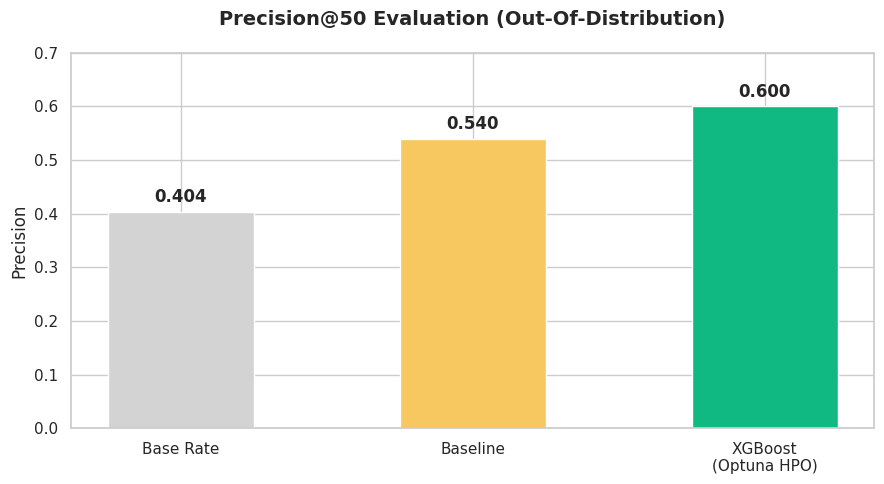

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns
from xgboost import plot_importance
import shap

sns.set_theme(style="whitegrid", palette="muted")

#Figure 1: Model and Basleine Comaprison
plt.figure(figsize=(9, 5))
labels = ['Base Rate', 'Baseline', 'XGBoost\n(Optuna HPO)']
scores = [0.404, 0.540, 0.600]
colors = ['#d3d3d3', '#f6c85f', '#10b981']

bars = plt.bar(labels, scores, color=colors, width=0.5)
plt.title('Precision@50 Evaluation (Out-Of-Distribution)', fontsize=14, pad=20, fontweight='bold')
plt.ylabel('Precision', fontsize=12)
plt.ylim(0, 0.7)

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.01, f'{yval:.3f}', ha='center', va='bottom', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('fig_1_baseline_comparison.png', dpi=300)
plt.show()

## 5. Limitations

*What this work cannot claim.*

This model provides a measured risk score, not a guaranteed prediction. An initial iteration that heavily relied on raw authority metrics (e.g., click_value, backlinks, search volume) suffered from severe OOD overfitting, dropping precision to around 0.240 or less. This highlights a crucial limitation: ML models in SEO should not blindly learn from raw authority values, as they fail to generalize across diverse domains. Furthermore, the model's accuracy is subject to variance depending on the specific volatility of the tested client portfolio.

Furthermore, the localized 15-day rolling window was a deliberate architectural compromise dictated by the RAM and compute constraints of the experimental environment, as well as the 4-month bound of the available dataset. Expanding the feature engineering to include 90-day macro-trends or Year-over-Year (YoY) comparisons to fully account for seasonality would require a distributed computing environment (e.g., PySpark) and a deeper historical data warehouse

## 6. Ranked recommendations

*The action playbook output — the paper's recommendations section.*

In [43]:
features = ['imp_past', 'ctr_past', 'avg_pos_past', 'sessions_past',
            'engagement_rate', 'scroll_rate', 'word_count', 'days_since_update',
            'days_visible_past', 'content_age', 'main_intent', 'competition', 'backlinks']

playbook_df = df2[df2['anchor_date'] == '2026-04-15'].copy()

playbook_df['risk_score'] = best_model.predict_proba(playbook_df[features])[:, 1]


conditions = [
    (playbook_df['risk_score'] > 0.50) & (playbook_df['content_age'] >= 180), #old and at risk
    (playbook_df['risk_score'] > 0.50) & (playbook_df['ctr_past'] < 1.0) & (playbook_df['avg_pos_past'] <= 20), #at risk, but at the first or second page - title or description need to be fixed
    (playbook_df['risk_score'] > 0.50) & (playbook_df['imp_past'] >= 1000) #at risk, but high visibility, near to the first page
]

actions = [
    'Refresh Mature Content (Age > 6 months)',
    'Urgent Snippet Rewrite (Low CTR)',
    'Boost High-Volume Edge (Expand the content)'
]

playbook_df['recommended_action'] = np.select(conditions, actions, default='Monitor')

playbook_queue = playbook_df[playbook_df['recommended_action'] != 'Monitor'].sort_values(
    by=['risk_score', 'click_value'], ascending=[False, False]
)

columns_to_export = [
    'client_hash_id', 'content_hash_id', 'risk_score', 'recommended_action',
    'click_value', 'imp_past', 'ctr_past', 'avg_pos_past', 'content_age'
]

top_20_playbook = playbook_queue[columns_to_export].head(20)

os.makedirs('work/outputs', exist_ok=True)
csv_path = 'work/outputs/action_playbook_queue.csv'
top_20_playbook.to_csv(csv_path, index=False)

print("TOP 5 RECOMMENDATIONS ")
display(top_20_playbook.head(5))

TOP 5 RECOMMENDATIONS 


,client_hash_id,content_hash_id,risk_score,recommended_action,click_value,imp_past,ctr_past,avg_pos_past,content_age
130263,client_65de48885f4ef01b,content_f018c8cb90d06162,0.923742,Refresh Mature Content (Age > 6 months),0.0,197.0,0.0,44.275468,249
208065,client_c182d11e4862a37d,content_5271624ae98fff86,0.858293,Refresh Mature Content (Age > 6 months),0.0,124.0,0.0,10.449092,246
128943,client_65de48885f4ef01b,content_365c47998240629b,0.824634,Refresh Mature Content (Age > 6 months),0.0,121.0,0.0,8.755378,247
129777,client_65de48885f4ef01b,content_a9e5a8f14112ddd3,0.821296,Refresh Mature Content (Age > 6 months),0.0,137.0,0.0,25.162357,251
130377,client_65de48885f4ef01b,content_fd994a655f0d049b,0.814835,Refresh Mature Content (Age > 6 months),0.0,121.0,0.0,4.297494,250


## 7. Artifacts the paper embeds

*Generate/collect the charts and tables your deployed page will show.*

<Figure size 1000x600 with 0 Axes>

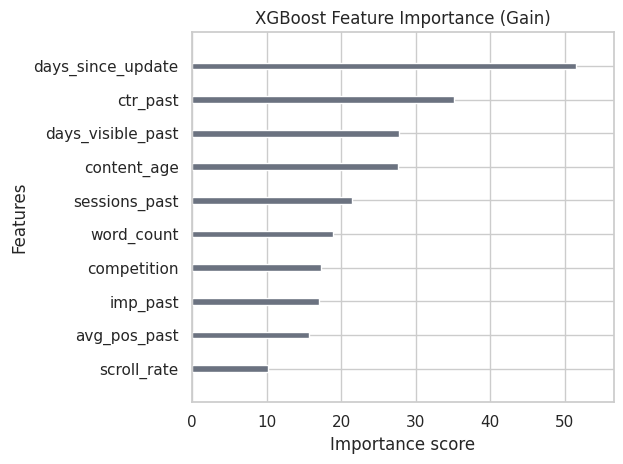

In [31]:
#Figure 2: Feature Importances (build-in)
plt.figure(figsize=(10, 6))
plot_importance(study.best_trial.user_attrs.get('model', best_model),
                importance_type='gain',
                max_num_features=10,
                color='#6b7280',
                title='XGBoost Feature Importance (Gain)',
                show_values=False)
plt.tight_layout()
plt.savefig('fig_2_feature_importance.png', dpi=300)
plt.show()

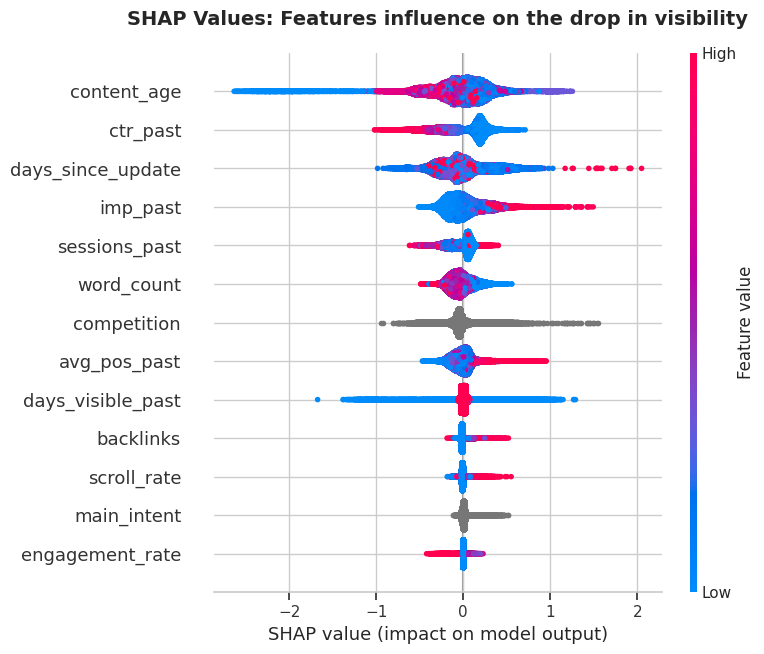

In [33]:
#Figure 3: SHAP
explainer = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(df2[test_mask][features])

plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, df2[test_mask][features], show=False)
plt.title('SHAP Values: Features influence on the drop in visibility', fontsize=14, pad=20, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_3_shap_summary.png', dpi=300)
plt.show()

These plots demonstrates that, when making decision splits, the algorithm prioritizes signals related to the article lifecycle and user behavior—specifically content freshness (`days_since_update`) and historical CTR (`ctr_past`).
SHAP analysis precisely explains the mechanism behind these traffic drops: the highest risk of traffic loss affects old pages that have not been updated for a long time (high `content_age` and `days_since_update` values) and those that fail to attract clicks (low `ctr_past` values).

## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.
- [ ] My deployed paper has **all 9 sections** — including the **Abstract** at the top and **Acknowledgments & data credit** (the https://flyrank.ai link) at the bottom.
- [ ] **ML-12 done in this notebook's closing cells:** 5-minute demo outline + a social-post cut + a 3-sentence employer-facing summary.

Acknowledgments & data credit: "Built on the FlyRank ML Internship dataset" (https://flyrank.ai).